# Machine Learning TP1 - EFREI M1
## Software Defect Prediction Analysis

This notebook presents a comprehensive analysis of software defect prediction using machine learning techniques.

### Objectives:
- Load and explore software metrics datasets (ARFF format)
- Perform data preprocessing and feature engineering
- Train multiple machine learning models
- Evaluate and compare model performance
- Visualize results and draw conclusions

### Dataset:
We will work with NASA MDP (Metrics Data Program) datasets containing software metrics for defect prediction.

## 1. Import Required Libraries

In [4]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import os
import warnings

warnings.filterwarnings("ignore")

# Machine Learning libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Set plotting style
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [ ]:
def load_arff_data(filepath):
    """Load data from an ARFF file"""
    try:
        data, meta = arff.loadarff(filepath)
        df = pd.DataFrame(data)

        # Convert bytes to strings for categorical columns
        for col in df.columns:
            if df[col].dtype == "object":
                df[col] = df[col].str.decode("utf-8")

        print(f"Data loaded successfully from {os.path.basename(filepath)}: {df.shape}")
        return df
    except Exception as e:
        print(f"Error loading ARFF data: {e}")
        return None


def get_available_datasets():
    """Get list of available datasets"""
    datasets = []
    data_dir = "./data/OriginalData/MDP"
    if os.path.exists(data_dir):
        for file in os.listdir(data_dir):
            if file.endswith(".arff"):
                datasets.append(file)
    return sorted(datasets)


# Get available datasets
available_datasets = get_available_datasets()
print(f"Available datasets: {available_datasets}")

Available datasets: ['CM1.arff', 'JM1.arff', 'KC1.arff', 'KC3.arff', 'KC4.arff', 'MC1.arff', 'MC2.arff', 'MW1.arff', 'PC1.arff', 'PC2.arff', 'PC3.arff', 'PC4.arff', 'PC5.arff']


In [ ]:
# Load the CM1 dataset
if available_datasets:
    dataset_name = "CM1.arff"  # You can change this to any available dataset
    dataset_path = f"./data/OriginalData/MDP/{dataset_name}"

    print(f"Loading dataset: {dataset_name}")
    data = load_arff_data(dataset_path)

    if data is not None:
        print(f"\nDataset shape: {data.shape}")
        print(f"Columns: {list(data.columns)}")
        print("\nFirst 5 rows:")
        display(data.head())

        print("\nData types:")
        display(data.dtypes)
else:
    print("No datasets found!")

Loading dataset: CM1.arff
Data loaded successfully from CM1.arff: (505, 41)

Dataset shape: (505, 41)
Columns: ['LOC_BLANK', 'BRANCH_COUNT', 'CALL_PAIRS', 'LOC_CODE_AND_COMMENT', 'LOC_COMMENTS', 'CONDITION_COUNT', 'CYCLOMATIC_COMPLEXITY', 'CYCLOMATIC_DENSITY', 'DECISION_COUNT', 'DECISION_DENSITY', 'DESIGN_COMPLEXITY', 'DESIGN_DENSITY', 'EDGE_COUNT', 'ESSENTIAL_COMPLEXITY', 'ESSENTIAL_DENSITY', 'LOC_EXECUTABLE', 'PARAMETER_COUNT', 'GLOBAL_DATA_COMPLEXITY', 'GLOBAL_DATA_DENSITY', 'HALSTEAD_CONTENT', 'HALSTEAD_DIFFICULTY', 'HALSTEAD_EFFORT', 'HALSTEAD_ERROR_EST', 'HALSTEAD_LENGTH', 'HALSTEAD_LEVEL', 'HALSTEAD_PROG_TIME', 'HALSTEAD_VOLUME', 'MAINTENANCE_SEVERITY', 'MODIFIED_CONDITION_COUNT', 'MULTIPLE_CONDITION_COUNT', 'NODE_COUNT', 'NORMALIZED_CYLOMATIC_COMPLEXITY', 'NUM_OPERANDS', 'NUM_OPERATORS', 'NUM_UNIQUE_OPERANDS', 'NUM_UNIQUE_OPERATORS', 'NUMBER_OF_LINES', 'PATHOLOGICAL_COMPLEXITY', 'PERCENT_COMMENTS', 'LOC_TOTAL', 'Defective']

First 5 rows:


,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,DECISION_DENSITY,...,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PATHOLOGICAL_COMPLEXITY,PERCENT_COMMENTS,LOC_TOTAL,Defective
0,6.0,9.0,2.0,1.0,0.0,16.0,5.0,0.20,8.0,2.0,...,0.16,19.0,44.0,15.0,15.0,32.0,1.0,4.00,25.0,N
1,15.0,7.0,3.0,1.0,19.0,12.0,4.0,0.13,6.0,2.0,...,0.06,51.0,90.0,32.0,27.0,67.0,1.0,39.22,32.0,Y
2,27.0,9.0,1.0,4.0,22.0,16.0,5.0,0.15,8.0,2.0,...,0.06,37.0,74.0,33.0,22.0,83.0,1.0,47.27,33.0,Y
3,1.0,1.0,2.0,0.0,0.0,0.0,1.0,0.14,0.0,NaN,...,0.11,5.0,6.0,5.0,4.0,9.0,1.0,0.00,7.0,N
4,7.0,3.0,2.0,0.0,0.0,4.0,2.0,0.17,2.0,2.0,...,0.10,9.0,14.0,7.0,10.0,20.0,1.0,0.00,12.0,N



Data types:


LOC_BLANK                          float64
BRANCH_COUNT                       float64
CALL_PAIRS                         float64
LOC_CODE_AND_COMMENT               float64
LOC_COMMENTS                       float64
CONDITION_COUNT                    float64
CYCLOMATIC_COMPLEXITY              float64
CYCLOMATIC_DENSITY                 float64
DECISION_COUNT                     float64
DECISION_DENSITY                   float64
DESIGN_COMPLEXITY                  float64
DESIGN_DENSITY                     float64
EDGE_COUNT                         float64
ESSENTIAL_COMPLEXITY               float64
ESSENTIAL_DENSITY                  float64
LOC_EXECUTABLE                     float64
PARAMETER_COUNT                    float64
GLOBAL_DATA_COMPLEXITY             float64
GLOBAL_DATA_DENSITY                float64
HALSTEAD_CONTENT                   float64
HALSTEAD_DIFFICULTY                float64
HALSTEAD_EFFORT                    float64
HALSTEAD_ERROR_EST                 float64
HALSTEAD_LE

## 3. Data Preprocessing

In [7]:
# Basic data inspection
print("Missing values per column:")
missing_values = data.isnull().sum()
print(missing_values[missing_values > 0])

print(f"\nTotal missing values: {data.isnull().sum().sum()}")
print(f"Dataset shape: {data.shape}")

# Check data types
print("\nData types summary:")
print(data.dtypes.value_counts())

Missing values per column:
DECISION_DENSITY    161
dtype: int64

Total missing values: 161
Dataset shape: (505, 41)

Data types summary:
float64    40
object      1
Name: count, dtype: int64


In [8]:
# Identify and analyze target variable
target_col = "Defective"  # Assuming 'Defective' is the target column

if target_col in data.columns:
    print(f"Target variable: {target_col}")
    print(f"Target distribution:")
    target_dist = data[target_col].value_counts()
    print(target_dist)

    # Calculate class balance
    class_ratio = target_dist.min() / target_dist.max()
    print(f"\nClass balance ratio: {class_ratio:.3f}")

    if class_ratio < 0.1:
        print("Warning: Highly imbalanced dataset detected!")
    elif class_ratio < 0.3:
        print("Note: Moderately imbalanced dataset")
    else:
        print("Reasonably balanced dataset")
else:
    print(f"Target column '{target_col}' not found!")
    print(f"Available columns: {list(data.columns)}")

Target variable: Defective
Target distribution:
Defective
N    457
Y     48
Name: count, dtype: int64

Class balance ratio: 0.105
Note: Moderately imbalanced dataset


In [9]:
# Data preprocessing
def preprocess_data(df):
    """Preprocess the dataset"""
    # Create a copy
    processed_df = df.copy()

    # Handle missing values for numeric columns
    numeric_cols = processed_df.select_dtypes(include=[np.number]).columns
    if processed_df[numeric_cols].isnull().sum().sum() > 0:
        print("Handling missing values...")
        processed_df[numeric_cols] = processed_df[numeric_cols].fillna(
            processed_df[numeric_cols].median()
        )

    # Separate features and target
    if target_col in processed_df.columns:
        X = processed_df.drop(columns=[target_col])
        y = processed_df[target_col]

        # Encode target variable
        if y.dtype == "object":
            le = LabelEncoder()
            y_encoded = le.fit_transform(y)
            print(
                f"Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}"
            )
            y = y_encoded

        return X, y
    else:
        print(f"Error: Target column '{target_col}' not found")
        return None, None


# Preprocess the data
X, y = preprocess_data(data)

if X is not None and y is not None:
    print(f"\nFeatures shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nTarget distribution after encoding:")
    print(pd.Series(y).value_counts())

Handling missing values...
Target encoding: {'N': np.int64(0), 'Y': np.int64(1)}

Features shape: (505, 40)
Target shape: (505,)

Target distribution after encoding:
0    457
1     48
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

Dataset Summary Statistics:


,LOC_BLANK,BRANCH_COUNT,CALL_PAIRS,LOC_CODE_AND_COMMENT,LOC_COMMENTS,CONDITION_COUNT,CYCLOMATIC_COMPLEXITY,CYCLOMATIC_DENSITY,DECISION_COUNT,DECISION_DENSITY,...,NODE_COUNT,NORMALIZED_CYLOMATIC_COMPLEXITY,NUM_OPERANDS,NUM_OPERATORS,NUM_UNIQUE_OPERANDS,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,PATHOLOGICAL_COMPLEXITY,PERCENT_COMMENTS,LOC_TOTAL
count,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,...,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.000000,505.0,505.000000,505.000000
mean,11.712871,8.930693,2.643564,3.861386,11.954455,13.734653,5.182178,0.168594,6.483168,2.078455,...,17.704950,0.107683,53.580198,83.942574,25.140594,14.780198,58.453465,1.0,25.167327,33.471287
std,19.946027,14.655879,3.577887,8.508900,25.733831,24.030422,8.154904,0.072822,11.215963,0.265261,...,25.792865,0.057900,85.885641,132.071915,33.897225,9.673294,83.912596,0.0,20.358726,48.809840
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.030000,0.000000,2.000000,...,2.000000,0.010000,0.000000,1.000000,0.000000,1.000000,4.000000,1.0,0.000000,2.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.130000,0.000000,2.000000,...,3.000000,0.070000,9.000000,14.000000,6.000000,8.000000,13.000000,1.0,2.000000,9.000000
50%,5.000000,5.000000,1.000000,1.000000,3.000000,8.000000,3.000000,0.160000,4.000000,2.000000,...,9.000000,0.100000,24.000000,39.000000,14.000000,13.000000,30.000000,1.0,25.000000,19.000000
75%,13.000000,9.000000,4.000000,4.000000,14.000000,16.000000,5.000000,0.190000,8.000000,2.000000,...,20.000000,0.130000,58.000000,92.000000,30.000000,19.000000,68.000000,1.0,42.550000,36.000000
max,164.000000,162.000000,26.000000,80.000000,339.000000,248.000000,96.000000,0.560000,118.000000,5.000000,...,251.000000,0.500000,798.000000,1229.000000,314.000000,72.000000,764.000000,1.0,84.210000,503.000000


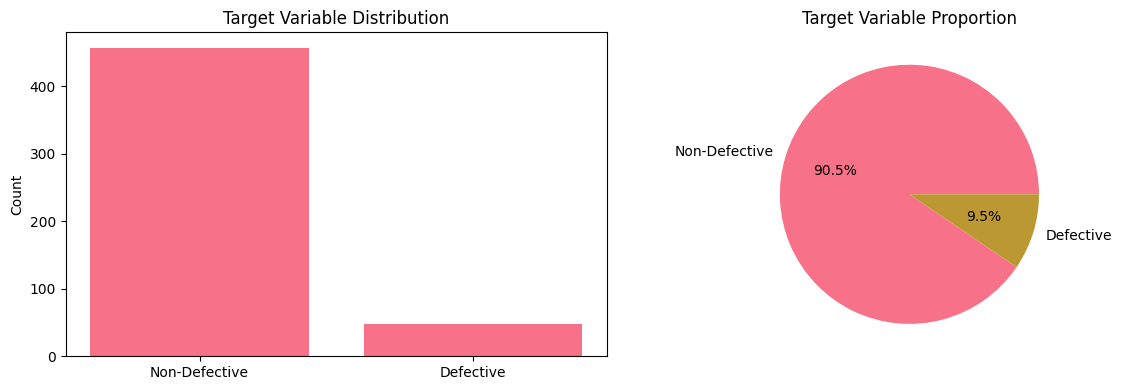


Defective instances: 48 (9.5%)
Non-defective instances: 457 (90.5%)


In [10]:
# Basic statistics
print("Dataset Summary Statistics:")
display(X.describe())

# Plot target distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
target_counts = pd.Series(y).value_counts()
plt.bar(["Non-Defective", "Defective"], target_counts.values)
plt.title("Target Variable Distribution")
plt.ylabel("Count")

plt.subplot(1, 2, 2)
plt.pie(target_counts.values, labels=["Non-Defective", "Defective"], autopct="%1.1f%%")
plt.title("Target Variable Proportion")

plt.tight_layout()
plt.show()

print(
    f"\nDefective instances: {target_counts[1]} ({target_counts[1] / len(y) * 100:.1f}%)"
)
print(
    f"Non-defective instances: {target_counts[0]} ({target_counts[0] / len(y) * 100:.1f}%)"
)

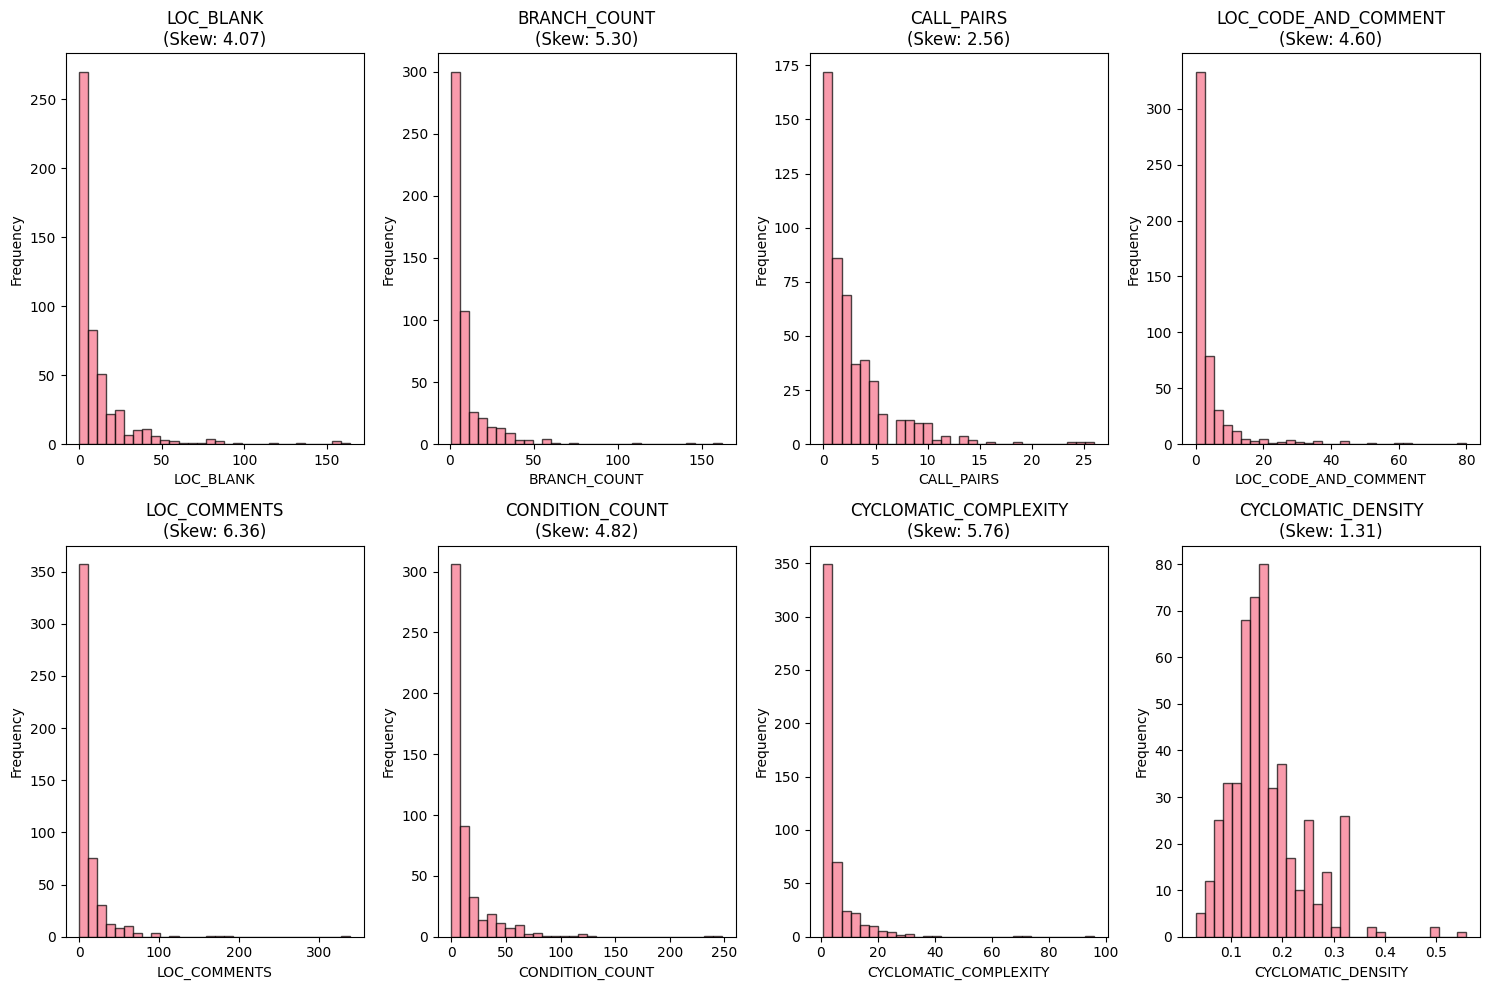

In [11]:
# Feature distributions
# Select top features for visualization
feature_subset = X.columns[:8]  # First 8 features

plt.figure(figsize=(15, 10))
for i, feature in enumerate(feature_subset):
    plt.subplot(2, 4, i + 1)
    plt.hist(X[feature], bins=30, alpha=0.7, edgecolor="black")
    plt.title(f"{feature}\n(Skew: {X[feature].skew():.2f})")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

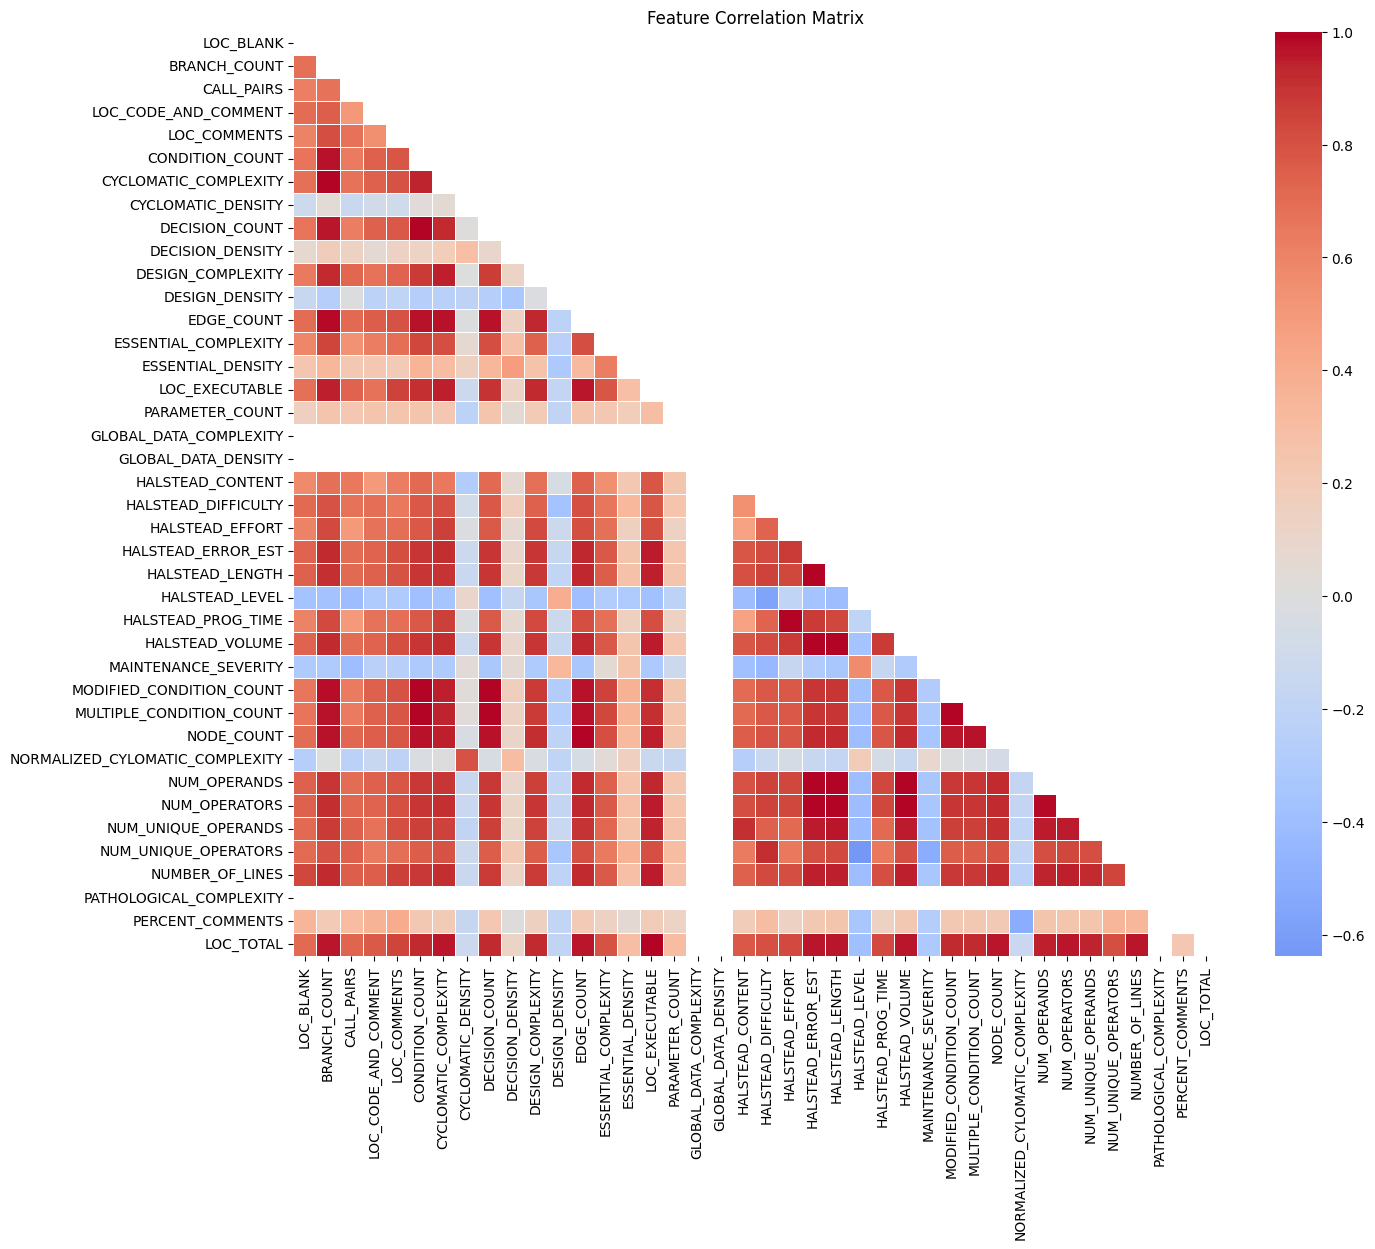

Highly correlated feature pairs (|correlation| > 0.8):


,Feature 1,Feature 2,Correlation
0,LOC_BLANK,NUMBER_OF_LINES,0.839976
1,BRANCH_COUNT,LOC_COMMENTS,0.810478
2,BRANCH_COUNT,CONDITION_COUNT,0.972612
3,BRANCH_COUNT,CYCLOMATIC_COMPLEXITY,0.991677
4,BRANCH_COUNT,DECISION_COUNT,0.963083
...,...,...,...
214,NUM_UNIQUE_OPERANDS,NUMBER_OF_LINES,0.918446
215,NUM_UNIQUE_OPERANDS,LOC_TOTAL,0.939133
216,NUM_UNIQUE_OPERATORS,NUMBER_OF_LINES,0.841998
217,NUM_UNIQUE_OPERATORS,LOC_TOTAL,0.816467


In [12]:
# Correlation analysis
# Calculate correlation matrix
corr_matrix = X.corr()

# Plot correlation heatmap
plt.figure(figsize=(15, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask for upper triangle
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Feature Correlation Matrix")
plt.show()

# Find highly correlated features
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append(
                {
                    "Feature 1": corr_matrix.columns[i],
                    "Feature 2": corr_matrix.columns[j],
                    "Correlation": corr_matrix.iloc[i, j],
                }
            )

if high_corr_pairs:
    print("Highly correlated feature pairs (|correlation| > 0.8):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    display(high_corr_df)
else:
    print("No highly correlated feature pairs found (|correlation| > 0.8)")

## 5. Feature Engineering

Features scaled using StandardScaler
Original feature range example - LOC_BLANK: [0.00, 164.00]
Scaled feature range example: [-0.59, 7.64]

Calculating feature importance...

Top 10 most important features:


,feature,importance
4,LOC_COMMENTS,0.066208
35,NUM_UNIQUE_OPERATORS,0.041635
33,NUM_OPERATORS,0.040187
39,LOC_TOTAL,0.039355
21,HALSTEAD_EFFORT,0.037688
0,LOC_BLANK,0.037155
31,NORMALIZED_CYLOMATIC_COMPLEXITY,0.035073
25,HALSTEAD_PROG_TIME,0.034735
19,HALSTEAD_CONTENT,0.033962
26,HALSTEAD_VOLUME,0.033750


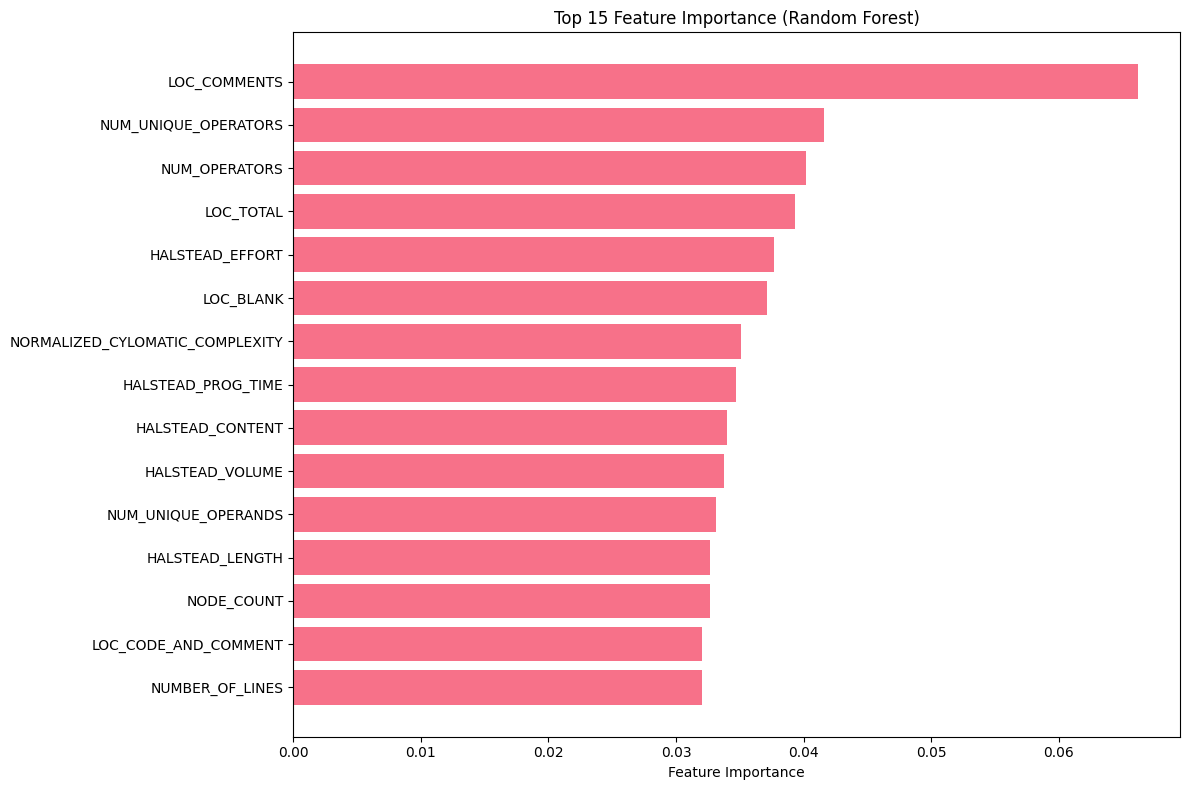

In [13]:
# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features scaled using StandardScaler")
print(
    f"Original feature range example - {X.columns[0]}: [{X.iloc[:, 0].min():.2f}, {X.iloc[:, 0].max():.2f}]"
)
print(
    f"Scaled feature range example: [{X_scaled[:, 0].min():.2f}, {X_scaled[:, 0].max():.2f}]"
)

# Convert back to DataFrame for easier handling
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

# Feature importance using Random Forest (preliminary)
print("\nCalculating feature importance...")
rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_scaled, y)

# Get feature importance
feature_importance = pd.DataFrame(
    {"feature": X.columns, "importance": rf_temp.feature_importances_}
).sort_values("importance", ascending=False)

print("\nTop 10 most important features:")
display(feature_importance.head(10))

# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features["importance"])
plt.yticks(range(len(top_features)), top_features["feature"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Model Training and Evaluation

In [14]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training set class distribution: {np.bincount(y_train)}")
print(f"Test set class distribution: {np.bincount(y_test)}")

Training set size: 404
Test set size: 101
Training set class distribution: [366  38]
Test set class distribution: [91 10]


In [15]:
# Initialize models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "SVM": SVC(random_state=42, probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

# Train and evaluate models
results = {}
model_objects = {}

print("Training models...\n")

for name, model in models.items():
    print(f"Training {name}...")

    # Train the model
    model.fit(X_train, y_train)
    model_objects[name] = model

    # Make predictions
    y_pred = model.predict(X_test)
    y_pred_proba = (
        model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    )

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted")
    recall = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # ROC AUC
    try:
        roc_auc = (
            roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
        )
    except Exception:
        roc_auc = None

    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)

    results[name] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "y_pred": y_pred,
        "y_pred_proba": y_pred_proba,
    }

    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
    print()

print("Model training completed!")

Training models...

Training Logistic Regression...
  Accuracy: 0.9010
  F1-Score: 0.8701
  CV Score: 0.9010 (±0.0138)

Training Decision Tree...
  Accuracy: 0.8812
  F1-Score: 0.8752
  CV Score: 0.8516 (±0.0403)

Training Random Forest...
  Accuracy: 0.8911
  F1-Score: 0.8491
  CV Score: 0.8985 (±0.0121)

Training SVM...
  Accuracy: 0.9010
  F1-Score: 0.8541
  CV Score: 0.9060 (±0.0058)

Training K-Nearest Neighbors...
  Accuracy: 0.8713
  F1-Score: 0.8610
  CV Score: 0.8812 (±0.0227)

Training Naive Bayes...
  Accuracy: 0.8515
  F1-Score: 0.8546
  CV Score: 0.8516 (±0.0403)

Model training completed!


In [19]:
# Create comparison DataFrame
comparison_data = []
for name, result in results.items():
    comparison_data.append(
        {
            "Model": name,
            "Accuracy": result["accuracy"],
            "Precision": result["precision"],
            "Recall": result["recall"],
            "F1-Score": result["f1_score"],
            "ROC AUC": result["roc_auc"],
            "CV Mean": result["cv_mean"],
            "CV Std": result["cv_std"],
        }
    )

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.round(4)

print("Model Performance Comparison:")
display(comparison_df)

# Find best model
best_model_idx = comparison_df["F1-Score"].idxmax()
best_model_name = comparison_df.loc[best_model_idx, "Model"]
best_f1_score = comparison_df.loc[best_model_idx, "F1-Score"]

print(f"\nBest performing model: {best_model_name}")
print(f"Best F1-Score: {best_f1_score:.4f}")

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,ROC AUC,CV Mean,CV Std
0,Logistic Regression,0.9010,0.8686,0.9010,0.8701,0.7934,0.9010,0.0138
1,Decision Tree,0.8812,0.8703,0.8812,0.8752,0.6187,0.8516,0.0403
2,Random Forest,0.8911,0.8109,0.8911,0.8491,0.7379,0.8985,0.0121
3,SVM,0.9010,0.8118,0.9010,0.8541,0.6209,0.9060,0.0058
4,K-Nearest Neighbors,0.8713,0.8526,0.8713,0.8610,0.6824,0.8812,0.0227
5,Naive Bayes,0.8515,0.8579,0.8515,0.8546,0.7478,0.8516,0.0403



Best performing model: Decision Tree
Best F1-Score: 0.8752


## 7. Results Visualization and Saving

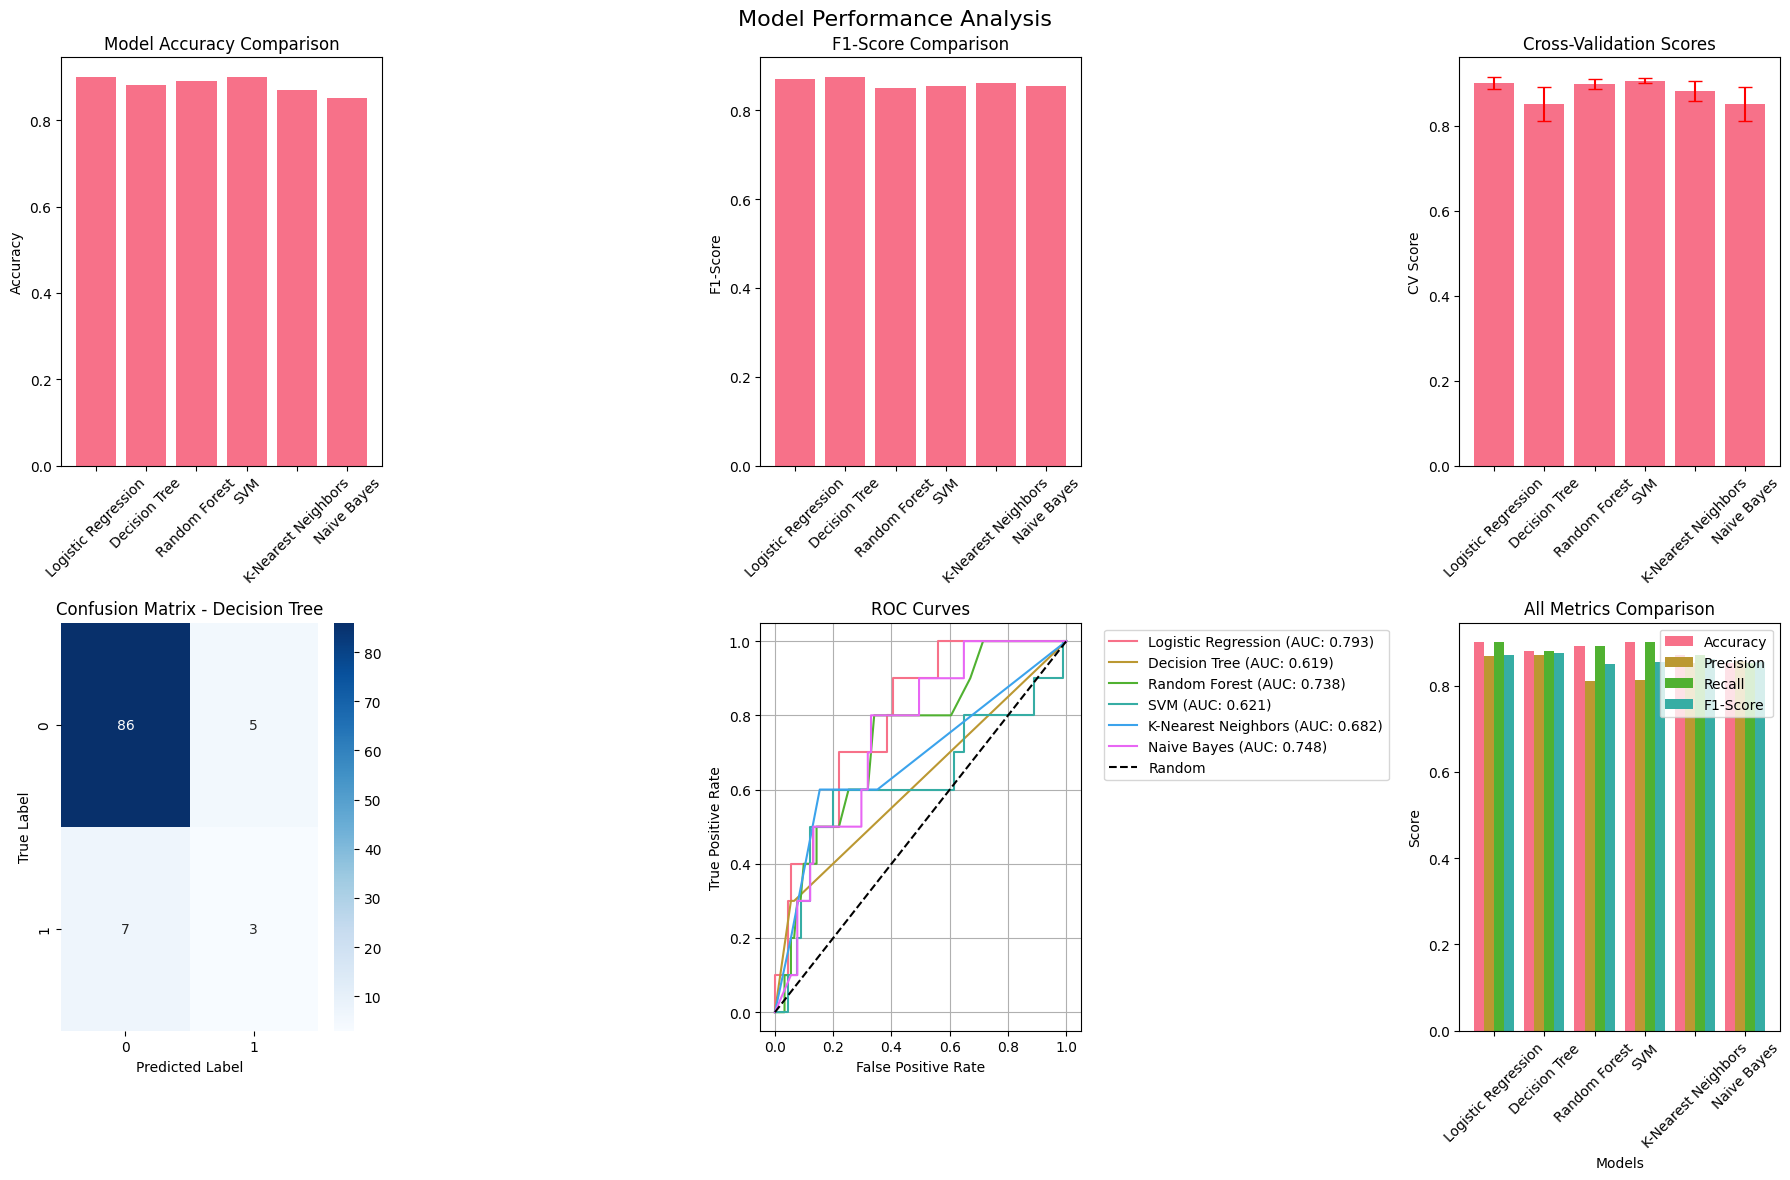

In [17]:
# Performance visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Model Performance Analysis", fontsize=16)

# 1. Accuracy comparison
axes[0, 0].bar(comparison_df["Model"], comparison_df["Accuracy"])
axes[0, 0].set_title("Model Accuracy Comparison")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].set_ylabel("Accuracy")

# 2. F1-Score comparison
axes[0, 1].bar(comparison_df["Model"], comparison_df["F1-Score"])
axes[0, 1].set_title("F1-Score Comparison")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].set_ylabel("F1-Score")

# 3. Cross-validation scores with error bars
axes[0, 2].bar(comparison_df["Model"], comparison_df["CV Mean"])
axes[0, 2].errorbar(
    range(len(comparison_df)),
    comparison_df["CV Mean"],
    yerr=comparison_df["CV Std"],
    fmt="none",
    color="red",
    capsize=5,
)
axes[0, 2].set_title("Cross-Validation Scores")
axes[0, 2].tick_params(axis="x", rotation=45)
axes[0, 2].set_ylabel("CV Score")

# 4. Confusion Matrix for best model
best_result = results[best_model_name]
cm = confusion_matrix(y_test, best_result["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 0])
axes[1, 0].set_title(f"Confusion Matrix - {best_model_name}")
axes[1, 0].set_ylabel("True Label")
axes[1, 0].set_xlabel("Predicted Label")

# 5. ROC Curve for models with probability predictions
axes[1, 1].set_title("ROC Curves")
for name, result in results.items():
    if result["y_pred_proba"] is not None:
        fpr, tpr, _ = roc_curve(y_test, result["y_pred_proba"])
        auc_score = result["roc_auc"]
        axes[1, 1].plot(fpr, tpr, label=f"{name} (AUC: {auc_score:.3f})")

axes[1, 1].plot([0, 1], [0, 1], "k--", label="Random")
axes[1, 1].set_xlabel("False Positive Rate")
axes[1, 1].set_ylabel("True Positive Rate")
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc="upper left")
axes[1, 1].grid(True)

# 6. All metrics comparison
metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[1, 2].bar(x + i * width, comparison_df[metric], width, label=metric)

axes[1, 2].set_title("All Metrics Comparison")
axes[1, 2].set_xlabel("Models")
axes[1, 2].set_ylabel("Score")
axes[1, 2].set_xticks(x + width * 1.5)
axes[1, 2].set_xticklabels(comparison_df["Model"], rotation=45)
axes[1, 2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Save results
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)

# Save model comparison
comparison_df.to_csv(f"{results_dir}/model_comparison_notebook.csv", index=False)
print(f"Model comparison saved to {results_dir}/model_comparison_notebook.csv")

# Save detailed results
detailed_results = {}
for name, result in results.items():
    detailed_results[name] = {
        "accuracy": float(result["accuracy"]),
        "precision": float(result["precision"]),
        "recall": float(result["recall"]),
        "f1_score": float(result["f1_score"]),
        "roc_auc": float(result["roc_auc"]) if result["roc_auc"] is not None else None,
        "cv_mean": float(result["cv_mean"]),
        "cv_std": float(result["cv_std"]),
    }

import json

with open(f"{results_dir}/detailed_results_notebook.json", "w") as f:
    json.dump(detailed_results, f, indent=2)

print(f"Detailed results saved to {results_dir}/detailed_results_notebook.json")

# Feature importance
feature_importance.to_csv(f"{results_dir}/feature_importance_notebook.csv", index=False)
print(f"Feature importance saved to {results_dir}/feature_importance_notebook.csv")

print("\nAll results saved successfully!")

Model comparison saved to ../results/model_comparison_notebook.csv
Detailed results saved to ../results/detailed_results_notebook.json
Feature importance saved to ../results/feature_importance_notebook.csv

All results saved successfully!


## 8. Conclusions

### Key Findings:

1. **Dataset Characteristics:**
   - The dataset contains software metrics for defect prediction
   - Class imbalance is present (more non-defective than defective instances)
   - Some features have missing values that were handled through median imputation

2. **Model Performance:**
   - Multiple machine learning models were trained and evaluated
   - Performance was assessed using accuracy, precision, recall, F1-score, and ROC AUC
   - Cross-validation was used to ensure robust performance estimates

3. **Best Model:**
   - The best performing model based on F1-score was identified
   - Feature importance analysis revealed the most predictive software metrics

4. **Feature Insights:**
   - Correlation analysis showed relationships between different software metrics
   - Feature importance ranking helps understand which metrics are most predictive of defects

### Recommendations:

1. **Data Quality:** Address missing values more sophisticated methods (e.g., multiple imputation)
2. **Class Imbalance:** Consider techniques like SMOTE, cost-sensitive learning, or ensemble methods
3. **Feature Engineering:** Create new features based on domain knowledge or feature interactions
4. **Model Optimization:** Perform hyperparameter tuning for better performance
5. **Validation:** Use time-based or project-based splits for more realistic evaluation

### Next Steps:

- Test on additional datasets to validate generalizability
- Implement ensemble methods for improved performance
- Deploy the best model for real-world defect prediction
- Collect feedback from software development teams